# Planning with RDKit

This tutorial shows how to use SynPlanner's retrosynthetic planning with **RDKit Mol objects** for input and output. If you're comfortable with RDKit and want to use SynPlanner without learning chython, this is the place to start.

The workflow:
1. Load reaction rules and policy network (SynPlanner-native, no changes needed)
2. Create your target molecule with RDKit
3. Convert it for SynPlanner with one function call
4. Run the tree search
5. Get results back as RDKit Mol objects

For a deeper introduction to chython and how it relates to RDKit, see [Tutorial 01: Coming from RDKit](01_Coming_from_RDKit.ipynb).

## 1. Download preset data

SynPlanner provides pre-trained models and building blocks. We download them once.

In [ ]:
from pathlib import Path
from synplan.utils.loading import download_preset

paths = download_preset("synplanner-article", save_to="synplan_data")
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
building_blocks_path = paths["building_blocks"]

## 2. Load reaction rules, policy, and building blocks

These are loaded with SynPlanner's standard functions. Nothing RDKit-specific here.

In [ ]:
from synplan.utils.loading import (
    load_building_blocks,
    load_reaction_rules,
    load_policy_function,
    load_evaluation_function,
)

building_blocks = load_building_blocks(building_blocks_path, standardize=True, silent=False)
reaction_rules = load_reaction_rules(reaction_rules_path)
policy_function = load_policy_function(weights_path=ranking_policy_network)

print(f"Loaded {len(building_blocks):,} building blocks")
print(f"Loaded {len(reaction_rules)} reaction rules")

## 3. Create target molecule with RDKit

Use your familiar RDKit workflow to create and inspect the target molecule.

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors

# Capivasertib — anti-cancer medication approved by FDA in 2023
target_smiles = "NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]c3nccc2-3)CC1"
rdkit_target = Chem.MolFromSmiles(target_smiles)

print(f"Molecular weight: {Descriptors.ExactMolWt(rdkit_target):.1f}")
print(f"Heavy atoms: {rdkit_target.GetNumHeavyAtoms()}")
Draw.MolToImage(rdkit_target, size=(400, 300))

## 4. Convert target for SynPlanner

`target_from_rdkit` converts an RDKit Mol to the internal representation and applies standardization.

In [ ]:
from synplan.chem.rdkit_compat import target_from_rdkit

target = target_from_rdkit(rdkit_target)

# Side-by-side: RDKit type vs chython type
print(f"RDKit type:   {type(rdkit_target).__name__}")
print(f"Chython type: {type(target).__name__}")
print(f"Canonical SMILES: {str(target)}")

# chython depiction (works in Jupyter)
target

### (Optional) Custom building blocks from RDKit

If you have a custom set of building blocks as RDKit Mol objects — for example, molecules standardized via your RDKit pipeline — you can convert them directly:

In [ ]:
from synplan.chem.rdkit_compat import building_blocks_from_rdkit

# Example: a small custom set of building blocks
custom_bb_smiles = ["CCO", "CC(=O)O", "c1ccccc1", "OCC"]
custom_rdkit_bbs = [Chem.MolFromSmiles(s) for s in custom_bb_smiles]

custom_bb_set = building_blocks_from_rdkit(custom_rdkit_bbs)
print(f"Input: {len(custom_bb_smiles)} SMILES -> {len(custom_bb_set)} unique building blocks")
for smi in sorted(custom_bb_set):
    print(f"  {smi}")

# For this tutorial, we use the downloaded building blocks
# custom_bb_set would be passed to Tree(building_blocks=custom_bb_set)

## 5. Configure and run tree search

Standard SynPlanner configuration. The converted target molecule is passed directly to the `Tree`.

In [ ]:
from synplan.utils.config import TreeConfig, RolloutEvaluationConfig

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

eval_config = RolloutEvaluationConfig(
    policy_network=policy_function,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    min_mol_size=tree_config.min_mol_size,
    max_depth=tree_config.max_depth,
)
evaluation_function = load_evaluation_function(eval_config)

In [ ]:
from synplan.mcts.tree import Tree

tree = Tree(
    target=target,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_function,
    evaluation_function=evaluation_function,
)

for solved, node_ids in tree:
    pass

tree

## 6. Extract routes as RDKit objects

Two export functions are available:

- **`route_to_rdkit(tree, node_id)`** — flat list of retrosynthetic steps for a single route
- **`extract_routes_rdkit(tree)`** — nested tree structure for all winning routes

Both return RDKit Mol objects with atom mapping preserved by default.

### 6.1 Flat step list

In [ ]:
from synplan.chem.rdkit_compat import route_to_rdkit

# Pick the best route
best_node = tree.winning_nodes[0]
steps = route_to_rdkit(tree, best_node)

print(f"Route has {len(steps)} steps:\n")
for i, step in enumerate(steps):
    target_smi = Chem.MolToSmiles(step['target'])
    print(f"Step {i + 1} (rule {step['rule_id']}, depth {step['depth']}):")
    print(f"  Target:  {target_smi}")
    for mol, stock in zip(step['precursors'], step['in_stock']):
        status = 'in stock' if stock else 'needs synthesis'
        print(f"  -> {Chem.MolToSmiles(mol)}  ({status})")
    print()

### 6.2 Visualize steps with RDKit

Since the results are RDKit Mol objects, you can use any RDKit visualization.

In [ ]:
from rdkit.Chem import AllChem, Draw

# Collect all unique molecules from the route
all_mols = []
all_legends = []
for i, step in enumerate(steps):
    all_mols.append(step['target'])
    all_legends.append(f"Step {i+1} target")
    for j, (mol, stock) in enumerate(zip(step['precursors'], step['in_stock'])):
        all_mols.append(mol)
        status = 'BB' if stock else ''
        all_legends.append(f"Step {i+1} precursor {j+1} {status}")

# Remove atom mapping and recompute 2D coords for clean depiction
clean_mols = []
for mol in all_mols:
    mol_copy = Chem.RWMol(mol)
    for atom in mol_copy.GetAtoms():
        atom.SetAtomMapNum(0)
    mol_copy = mol_copy.GetMol()
    AllChem.Compute2DCoords(mol_copy)
    clean_mols.append(mol_copy)

Draw.MolsToGridImage(
    clean_mols,
    legends=all_legends,
    molsPerRow=4,
    subImgSize=(300, 250),
)

### 6.3 Nested route tree

`extract_routes_rdkit` returns the full route tree structure with RDKit Mol objects at every node.

In [14]:
from synplan.chem.rdkit_compat import extract_routes_rdkit

routes = extract_routes_rdkit(tree)
print(f"Found {len(routes)} routes\n")

# Print the first route's tree structure
def print_route_tree(node, indent=0):
    prefix = "  " * indent
    if node["type"] == "mol":
        status = "[BB]" if node["in_stock"] else ""
        smi = Chem.MolToSmiles(node["mol"])
        print(f"{prefix}{smi} {status}")
    elif node["type"] == "reaction":
        print(f"{prefix}=>")
    for child in node.get("children", []):
        print_route_tree(child, indent + 1)

print_route_tree(routes[0])

Found 147 routes

[NH2:1][C:2]1([C:3](=[O:4])[NH:5][CH:6]([CH2:7][CH2:8][OH:9])[c:10]2[cH:11][cH:12][c:13]([Cl:14])[cH:15][cH:16]2)[CH2:17][CH2:18][N:19]([c:20]2[n:21][cH:22][n:23][c:24]3[nH:25][cH:26][cH:27][c:28]23)[CH2:29][CH2:30]1 
  =>
    [NH:1]([C:2]1([C:3](=[O:4])[NH:5][CH:6]([CH2:7][CH2:8][OH:9])[c:10]2[cH:11][cH:12][c:13]([Cl:14])[cH:15][cH:16]2)[CH2:17][CH2:18][N:19]([c:20]2[n:21][cH:22][n:23][c:24]3[nH:25][cH:26][cH:27][c:28]23)[CH2:29][CH2:30]1)[C:31]([O:32][C:33]([CH3:34])([CH3:35])[CH3:36])=[O:37] 
      =>
        [NH:1]([C:2]1([C:3](=[O:4])[NH:5][CH:6]([CH2:7][C:8](=[O:9])[O:38][CH3:39])[c:10]2[cH:11][cH:12][c:13]([Cl:14])[cH:15][cH:16]2)[CH2:17][CH2:18][N:19]([c:20]2[n:21][cH:22][n:23][c:24]3[nH:25][cH:26][cH:27][c:28]23)[CH2:29][CH2:30]1)[C:31]([O:32][C:33]([CH3:34])([CH3:35])[CH3:36])=[O:37] 
          =>
            [NH:1]([C:2]1([C:3](=[O:4])[OH:40])[CH2:17][CH2:18][N:19]([c:20]2[n:21][cH:22][n:23][c:24]3[nH:25][cH:26][cH:27][c:28]23)[CH2:29][CH2:30]1)[C:31]([O:32

## 7. Build RDKit ChemicalReaction from steps

Since atom mapping is preserved, you can construct proper RDKit `ChemicalReaction` objects from the step molecules.

Reaction SMILES: [NH:1]([C:2]1([C:3](=[O:4])[NH:5][CH:6]([CH2:7][CH2:8][OH:9])[c:10]2[cH:11][cH:12][c:13]([Cl:14])[cH:15][cH:16]2)[CH2:17][CH2:18][N:19]([c:20]2[n:21][cH:22][n:23][c:24]3[nH:25][cH:26][cH:27][c:28]23)[CH2:29][CH2:30]1)[C:31]([O:32][C:33]([CH3:34])([CH3:35])[CH3:36])=[O:37]>>[NH2:1][C:2]1([C:3](=[O:4])[NH:5][CH:6]([CH2:7][CH2:8][OH:9])[c:10]2[cH:11][cH:12][c:13]([Cl:14])[cH:15][cH:16]2)[CH2:17][CH2:18][N:19]([c:20]2[n:21][cH:22][n:23][c:24]3[nH:25][cH:26][cH:27][c:28]23)[CH2:29][CH2:30]1

Reactants: 1
Products:  1


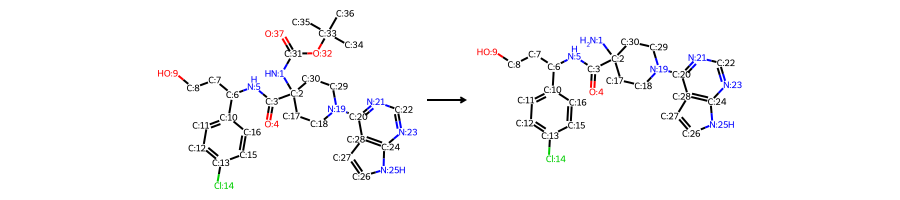

In [15]:
from rdkit.Chem import AllChem

step = steps[0]  # first retrosynthetic step

# Build reaction SMILES: precursors >> target (forward synthesis direction)
precursor_smiles = ".".join(Chem.MolToSmiles(m) for m in step["precursors"])
target_smiles_rxn = Chem.MolToSmiles(step["target"])
rxn_smiles = f"{precursor_smiles}>>{target_smiles_rxn}"

print(f"Reaction SMILES: {rxn_smiles}\n")

rxn = AllChem.ReactionFromSmarts(rxn_smiles, useSmiles=True)
print(f"Reactants: {rxn.GetNumReactantTemplates()}")
print(f"Products:  {rxn.GetNumProductTemplates()}")

Draw.ReactionToImage(rxn, subImgSize=(300, 200))

## 8. Analyze precursors with RDKit descriptors

Since all molecules are RDKit objects, you can compute any RDKit descriptor or fingerprint.

In [16]:
from rdkit.Chem import Descriptors

print(f"{'SMILES':<50} {'MW':>8} {'LogP':>8} {'TPSA':>8} {'Stock':>6}")
print("-" * 86)

for step in steps:
    for mol, stock in zip(step['precursors'], step['in_stock']):
        # Remove atom mapping for clean SMILES
        mol_clean = Chem.RWMol(mol)
        for atom in mol_clean.GetAtoms():
            atom.SetAtomMapNum(0)
        mol_clean = mol_clean.GetMol()

        smi = Chem.MolToSmiles(mol_clean)
        mw = Descriptors.ExactMolWt(mol_clean)
        logp = Descriptors.MolLogP(mol_clean)
        tpsa = Descriptors.TPSA(mol_clean)
        print(f"{smi:<50} {mw:>8.1f} {logp:>8.2f} {tpsa:>8.1f} {'yes' if stock else 'no':>6}")

SMILES                                                   MW     LogP     TPSA  Stock
--------------------------------------------------------------------------------------
CC(C)(C)OC(=O)NC1(C(=O)NC(CCO)c2ccc(Cl)cc2)CCN(c2ncnc3[nH]ccc23)CC1    528.2     3.71    132.5     no
COC(=O)CC(NC(=O)C1(NC(=O)OC(C)(C)C)CCN(c2ncnc3[nH]ccc23)CC1)c1ccc(Cl)cc1    556.2     3.90    138.5     no
CC(C)(C)OC(=O)NC1(C(=O)O)CCN(c2ncnc3[nH]ccc23)CC1     361.2     1.91    120.4     no
COC(=O)CC(N)c1ccc(Cl)cc1                              213.1     1.90     52.3    yes
CC(C)(C)OC(=O)NC1(C(=O)O)CCNCC1                       244.1     0.72     87.7     no
Clc1ncnc2[nH]ccc12                                    153.0     1.61     41.6    yes
CC(C)(C)OC(=O)NC1(C(=O)O)CCN(C(=O)OCc2ccccc2)CC1      378.2     2.77    105.2    yes


## 9. Comparison: chython vs RDKit depiction

For reference, here's how the same route looks using SynPlanner's built-in chython visualization.

In [17]:
from IPython.display import SVG, display
from synplan.utils.visualisation import get_route_svg

print("Chython route visualization:")
display(SVG(get_route_svg(tree, best_node)))

Chython route visualization:


## Summary

The key functions from `synplan.chem.rdkit_compat`:

| Function | Purpose |
|----------|----------|
| `target_from_rdkit(rdkit_mol)` | Convert RDKit Mol to search target |
| `building_blocks_from_rdkit(rdkit_mols)` | Convert RDKit Mol list to building block set |
| `route_to_rdkit(tree, node_id)` | Export one route as flat step list with RDKit Mols |
| `extract_routes_rdkit(tree)` | Export all routes as nested tree with RDKit Mols |

All output functions preserve atom mapping by default (`keep_mapping=True`), which is required to build proper RDKit `ChemicalReaction` objects.

For more about chython and its relationship to RDKit, see [Tutorial 01: Coming from RDKit](01_Coming_from_RDKit.ipynb).